# Phase Transitions of a xSM

In [ ]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import TwoSlopeNorm
import matplotlib.patheffects as pe
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

import pandas as pd

import multiprocessing as mp
from joblib import Parallel, delayed

from tqdm.notebook import tqdm

import os

from cosmoTransitions import transitionFinder
from cosmoTransitions import pathDeformation as pthd

from scipy.optimize import minimize, brentq
from scipy.optimize import minimize_scalar
from scipy.optimize import shgo

from time import perf_counter

import Higgs.predictions as HP
import Higgs.bounds as HB
import Higgs.signals as HS

pred = HP.Predictions()
bounds = HB.Bounds('/home/diegogt/hbdataset/')
signals = HS.Signals('/home/diegogt/hsdataset')

from xSM_Tadpole import xSMt as xSM

def physical_to_lagrangian(m1, m2, theta, v, lHS, lS, mu3):
    lH   = (m1**2 * np.cos(theta)**2 + m2**2 * np.sin(theta)**2)/(2 * v**2)
    muHS = np.sin(theta) * np.cos(theta) / v * (m1**2 - m2**2)
    muS2 = 0.5 * lHS * v**2 - (m1**2 * np.sin(theta)**2 + m2**2 * np.cos(theta)**2)
    muH2 = lH * v**2
    mu13 = - 0.5 * v**2 * muHS

    return dict(muH2=muH2, lH=lH, mu13=mu13, muHS=muHS, lHS=lHS, mu3=mu3, lS=lS, muS2=muS2)

## Examine the Potential 
(Specific Parameters)

In [ ]:
m1  = 125.20
m2  = 57.897959
th  = 0.0
v0  = 246.22
lHS = 0.002683
lS  = 0.001526
mu3 = 4.753764

params = physical_to_lagrangian(
    m1    = m1,
    m2    = m2,
    theta = th,
    v     = v0,
    lHS   = lHS,
    lS    = lS,
    mu3   = mu3
)

lH   = params["lH"]
lHS  = params["lHS"]
muHS = params["muHS"]
lS   = params["lS"]
mu3  = params["mu3"]
muH2 = params["muH2"]
muS2 = params["muS2"]
mu13 = params["mu13"]

lSmin = (lHS*v0**2-2*m2**2)**2/(2*v0**2*m1**2)

for i in params.keys():
    if i == "lS":
        print(f"{i} -> {params[i]}  lS min = {lSmin}")
    else:
        print(f"{i} -> {params[i]}")

model = xSM(**{k: params[k] for k in ['lH','lHS','muHS','lS','mu3', 'muS2']})
model.Tmax = 250
v = model.v_os
w = model.w_os

muH2 -> 7837.52
lH -> 0.1292801978686813
mu13 -> -0.0
muHS -> 0.0
lHS -> 0.09103
mu3 -> 17.720101
lS -> 0.033932  lS min = 0.0024761808690059485
muS2 -> -1084.685513474


### Tree-Level Potential

In [60]:
# --- Symmetric Extrema ---
coeffs = [lS,-mu3,-muS2, mu13]
roots = np.roots(coeffs)
real_roots = roots[np.abs(roots.imag) < 1e-8].real
d2V0 = -muS2 - 2.0 * mu3 * real_roots + 3.0 * lS * real_roots**2
minima_roots = real_roots[d2V0 > 0]

print("="*50)
print("    Symmetric Vaccua")
print("="*50)
print(f"The symmetric extrema are: {np.round(real_roots, 4)}")
print(f"The symmetric minima are: {np.round(minima_roots, 4)}")
print(f"The false vacuum is at s={w:.4f} GeV")
print()

# --- Non Symmetric Extrema ---
sp = (-muHS+(2*lHS*muH2+muHS**2)**0.5)/(lHS)
sm = (-muHS-(2*lHS*muH2+muHS**2)**0.5)/(lHS)

a = (lS - lHS**2/(4*lH))
b = -(mu3 + 3*lHS*muHS/(4*lH))
c = (lHS*muH2 - muHS**2 - 2*lH*muS2)/(2*lH)
d = (muH2*muHS)/(2*lH) + mu13
X = np.roots([a, b, c, d])
realX = X[np.abs(X.imag) < 1e-8].real
validX = realX[(sm < realX) & (realX < sp)]
d2V = (lHS*muH2 - muHS**2 - 2*lH*muS2)/(2*lH) - (mu3 + 3*lHS*muHS/(2*lH)) * validX + (lS - lHS**2/(4*lH)) * validX**2
minimaX = validX[d2V > 0]
root_hp  =  np.sqrt(-validX**2 * lHS + 2*muH2 - 2*validX*muHS) / (np.sqrt(2) * np.sqrt(lH))

print("="*50)
print("    Non-Symmetric Vaccua")
print("="*50)
print(f"The validity range of the Non-symmetric solutions is: [{sm:.4f},{sp:.4f}]")
print(f"The Non-Symmetric, valid, extrema are: {np.round(validX, 4)}, h-> {np.round(root_hp, 4)}")
print(f"The Non-Symmetric, valid, minima are: {np.round(minimaX, 4)}")
print()

print("="*50)
print("    Stability of the Potential")
print("="*50)
Vv = model.Vtot(np.array([[v, 0.0]]), 0.0)
Vw = model.Vtot(np.array([[0.0, w]]), 0.0)
print(f"V(v, 0) = {Vv[0]:.0f}")
print(f"V(0, w) = {Vw[0]:.0f}")

if Vv[0] < Vw[0]:
    print(f"The EW vaccum is stable")

if Vv[0] > Vw[0]:
    print(f"The EW vaccum is meta-stable")

    Symmetric Vaccua
The symmetric extrema are: [451.4091  70.8148   0.    ]
The symmetric minima are: [451.4091   0.    ]
The false vacuum is at s=451.4091 GeV

    Non-Symmetric Vaccua
The validity range of the Non-symmetric solutions is: [-414.9656,414.9656]
The Non-Symmetric, valid, extrema are: [321.174   0.   ], h-> [155.9097 246.22  ]
The Non-Symmetric, valid, minima are: [321.174   0.   ]

    Stability of the Potential
V(v, 0) = -118786018
V(0, w) = -80573402
The EW vaccum is stable


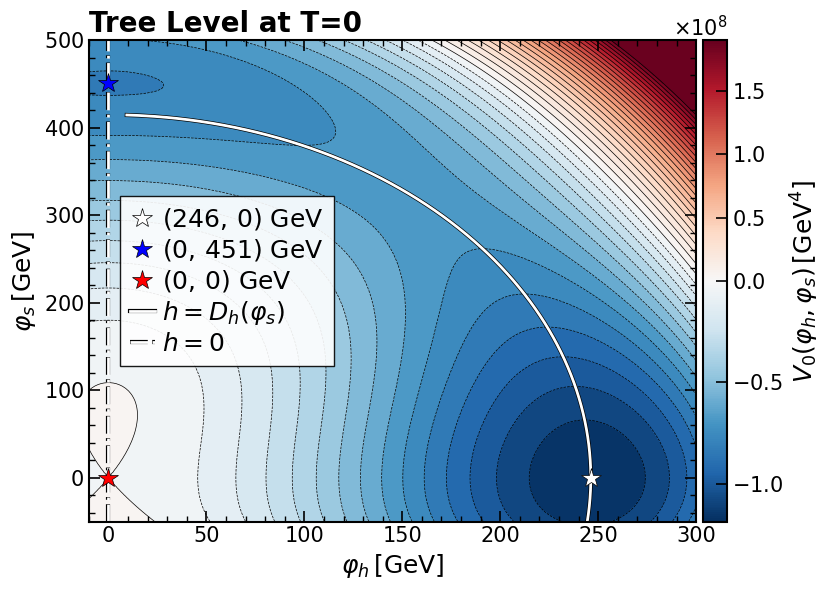

In [62]:
# Set the values of h & s 
hmin, hmax = (-10, 300)
smin, smax = (-50, 500)

# Create the Paths 
s_path  = np.linspace(smin, smax, 1000)
h_zeros = np.zeros_like(s_path)
h_plus  = np.full_like(s_path, np.nan)
h_minus = np.full_like(s_path, np.nan)

radicand = -s_path**2 * lHS + 2*muH2 - 2*s_path*muHS
valid = radicand >= 0
h_plus[valid]  =  np.sqrt(radicand[valid]) / (np.sqrt(2) * np.sqrt(lH))
h_minus[valid] = -np.sqrt(radicand[valid]) / (np.sqrt(2) * np.sqrt(lH))

# Potential Grid 
h_vals = np.linspace(hmin, hmax, 200)
s_vals = np.linspace(smin, smax, 200)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.V0(X_grid).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 99))
V_shifted = V_plot - model.V0(np.array([[0.0, 0.0]]))

# Normalize the cmap
norm = TwoSlopeNorm(vcenter=0, vmin=V_shifted.min(), vmax=V_shifted.max()) # Normalize(vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

# Create the Figure
fig, ax = plt.subplots(figsize=(8.5, 6))

cp = ax.contourf(H, S, V_shifted, levels=50, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=50, colors='k', linewidths=0.5, alpha=1)
ax.plot(root_hp[-1], validX[-1], 'w*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$({root_hp[-1]:.0f},\,{validX[-1]:.0f})$ GeV')
ax.plot(0, minima_roots[0], 'b*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$({0},\,{minima_roots[0]:.0f})$ GeV')
ax.plot(0, minima_roots[1], 'r*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$({0},\,{minima_roots[1]:.0f})$ GeV')
ax.plot(h_plus, s_path, label=r'$h=D_h(\varphi_s)$', color='w', lw=2, ls='-', path_effects=[pe.Stroke(linewidth=3, foreground='black'), pe.Normal()])
ax.plot(h_zeros, s_path, label=r'$h=0$', color='w', lw=2, ls='-.', path_effects=[pe.Stroke(linewidth=3, foreground='black'), pe.Normal()])

# Make it Pretty
ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_{0}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "center left", bbox_to_anchor=(0.03, 0.5),ncol = 1, edgecolor="black", framealpha=0.9, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Tree Level at T=0", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(f"Figures/TL_Contour.pdf", format="pdf", bbox_inches="tight")
plt.show()

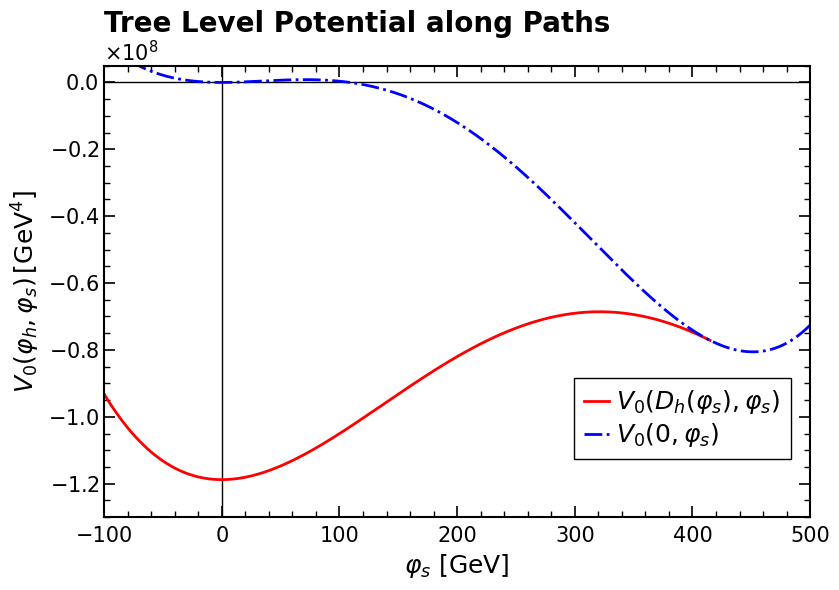

In [67]:
# Potential allong paths
sp = (-muHS+(2*lHS*muH2+muHS**2)**0.5)/(lHS)
sm = (-muHS-(2*lHS*muH2+muHS**2)**0.5)/(lHS)
SPath = np.linspace(sm,sp,500)
SPath0 = np.linspace(smin-500,smax+500,1000)

Vs0 = mu13*SPath0-0.5*muS2*SPath0**2-mu3/3*SPath0**3+lS/4*SPath0**4

Vs = (-(muH2**2)/(4*lH)
      + SPath*((muH2*muHS)/(2*lH) + mu13)
      - SPath**2*(-12*lHS*muH2 + 12*muHS**2 + 24*lH*muS2)/(48*lH)
      - SPath**3*(16*lH*mu3 + 12*lHS*muHS)/(48*lH)        
      - SPath**4*(3*lHS**2 - 12*lH*lS)/(48*lH))

# Create the plot
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(SPath, Vs, label=r'$V_{0}\left(D_h(\varphi_s),\varphi_s\right)$', color='r', lw=2, ls='-')
ax.plot(SPath0, Vs0, label=r'$V_{0}\left(0,\varphi_s\right)$', color='b', lw=2, ls='-.')

ax.set_xlim(-100, 500)
ax.set_ylim(-1.3e8, 0.5e7)

ax.set_xlabel(r'$\varphi_s$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_{0}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.1),
               ncol = 1, edgecolor="black", framealpha=1, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Tree Level Potential along Paths", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(f"Figures/TL_Path.pdf", format="pdf", bbox_inches="tight")
plt.show()

### Coleman Weinberg ($T=0$)

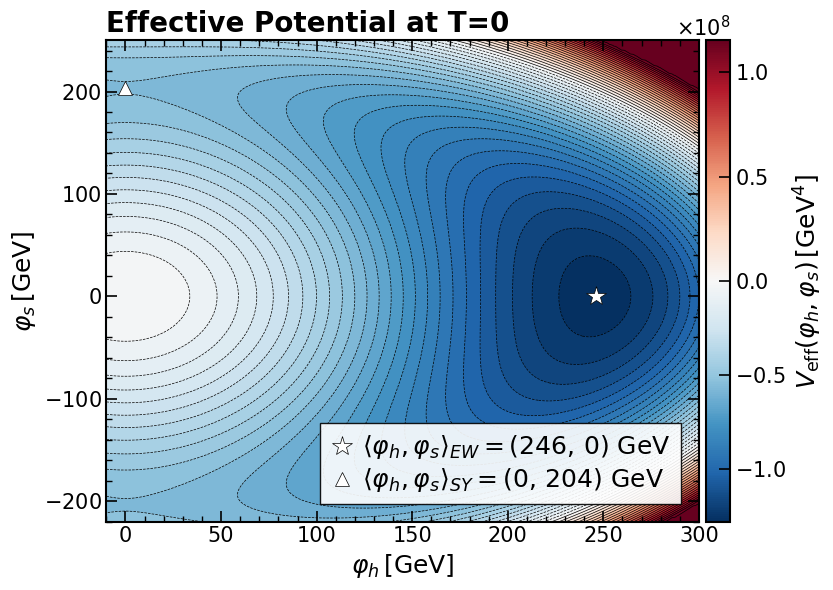

In [17]:
# Grid in (h, s)
h_vals = np.linspace(-10, 300, 200)
s_vals = np.linspace(-220, 250, 250)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.Vtot(X_grid, 0.0).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 99))
V_shifted = V_plot - model.Vtot(np.array([[0.0, 0.0]]), 0.0)

norm = TwoSlopeNorm(vcenter=0, vmin=V_shifted.min(), vmax=V_shifted.max()) # Normalize(vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

fig, ax = plt.subplots(figsize=(8.5, 6))

cp = ax.contourf(H, S, V_shifted, levels=50, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=50, colors='k', linewidths=0.5, alpha=1)
ax.plot(v, 0, 'w*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$\langle\varphi_h, \varphi_s\rangle_{{EW}} = ({v:.0f},\,{0:.0f})$ GeV')
ax.plot(0, w, 'w^', markersize=10, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'$\langle\varphi_h, \varphi_s\rangle_{{SY}} = ({0:.0f},\,{w:.0f})$ GeV')

ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_\mathrm{eff}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0.9, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Effective Potential at T=0", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(f"Figures/CW_Contour.pdf", format="pdf", bbox_inches="tight")
plt.show()

### Phase Transition

In [20]:
trans = model.calcTcTrans()
Tc   = trans[0]['Tcrit']
high = trans[0]['high_vev']
low  = trans[0]['low_vev']
xi_c = abs(low[0] - high[0]) / Tc
print(f"Tc = {Tc:.4f} GeV  |  xi_c = {xi_c:.2f}")

Tracing phase starting at x = [ 2.46220000e+02 -2.51570718e-06] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
...............................................................................................................
Tracing phase starting at x = [1.91583363e-06 1.42677154e+02] ; t = 94.69644919521053
Tracing minimum down
traceMinimum t0 = 94.6964
.................................................
Tracing minimum up
traceMinimum t0 = 94.6964
......................................
Tracing phase starting at x = [3.01085088e-06 1.45178741e+02] ; t = 36.803502685426494
Tracing minimum down
traceMinimum t0 = 36.8035
..........................................
Tracing minimum up
traceMinimum t0 = 36.8035
.............................................................................................................
Tc = 66.8726 GeV  |  xi_c = 3.57


In [21]:
# Compute the rest

trans = model.findAllTransitions()
print()
print("The Model has",len(model.TnTrans),"transition(s)")

if len(model.TnTrans) != 0:
    Trans = model.TnTrans[0]

    Tc    = Trans['crit_trans']['Tcrit']
    highc = Trans['crit_trans']['high_vev']
    lowc  = Trans['crit_trans']['low_vev']
    xic   = abs(lowc[0] - highc[0]) / Tc
    Tn    = Trans['Tnuc']
    highn = Trans['high_vev']
    lown  = Trans['low_vev']
    xin   = abs(lown[0] - highn[0]) / Tc

    print(f"Tc = {Tc:.4f} GeV  |  xi_c = {xi_c:.2f}")

Tunneling from phase 2 to phase 0 at T=35.96983
high_vev = [1.60949443e-04 1.45189879e+02]
low_vev = [ 2.45601739e+02 -3.93826546e-06]
Path deformation converged. 49 steps. fRatio = 1.79911e-02
Path deformation converged. 21 steps. fRatio = 1.60962e-02
Path deformation converged. 4 steps. fRatio = 4.91439e-03
Path deformation converged. 1 steps. fRatio = 4.56987e-03
Tunneling from phase 2 to phase 0 at T=35.97033
high_vev = [1.49351741e-04 1.45189872e+02]
low_vev = [ 2.45601702e+02 -3.97327728e-06]
Path deformation converged. 49 steps. fRatio = 1.79909e-02
Path deformation converged. 21 steps. fRatio = 1.60965e-02
Path deformation converged. 4 steps. fRatio = 5.24968e-03
Path deformation converged. 1 steps. fRatio = 4.79922e-03
Tunneling from phase 2 to phase 0 at T=65.20821
high_vev = [3.24921873e-06 1.44454515e+02]
low_vev = [2.39321907e+02 2.11324447e-06]
Path deformation converged. 54 steps. fRatio = 1.81045e-02
Path deformation converged. 20 steps. fRatio = 1.86463e-02
Path deform

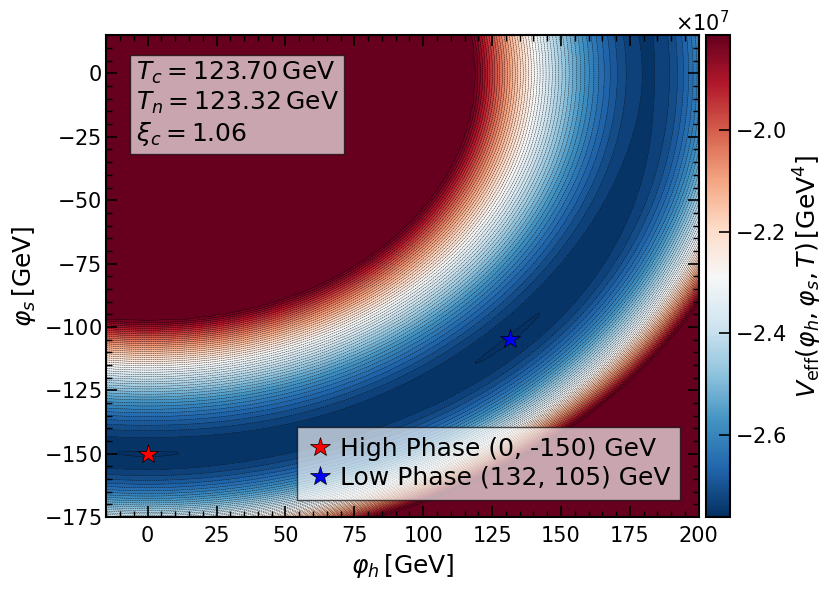

In [ ]:
# Grid in (h, s)
h_vals = np.linspace(-15, 200, 200)
s_vals = np.linspace(-175, 15, 200)
H, S   = np.meshgrid(h_vals, s_vals)
X_grid = np.column_stack([H.ravel(), S.ravel()])
V_grid = model.Vtot(X_grid, Tc).reshape(H.shape)
V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 60))
V_shifted = V_plot - model.Vtot(np.array([[0.0, 0.0]]), Tc)

norm = Normalize(vmin=V_shifted.min(), vmax=V_shifted.max())
sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

fig, ax = plt.subplots(figsize=(8.5, 6))

cp = ax.contourf(H, S, V_shifted, levels=55, cmap='RdBu_r', norm=norm)
ax.contour(H, S, V_shifted, levels=55, colors='k', linewidths=0.3, alpha=1)

ax.plot(high[0], high[1], 'r*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'High Phase ({high[0]:.0f}, {high[1]:.0f}) GeV')
ax.plot(low[0], low[1], 'b*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
        label=rf'Low Phase ({low[0]:.0f}, {-low[1]:.0f}) GeV')

ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1,   labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$V_\mathrm{eff}(\varphi_h,\varphi_s,T) \, [\mathrm{GeV^4}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)
cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
cbar.ax.yaxis.get_offset_text().set_fontsize(15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(-2,3))
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

ax.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01), 
          ncol = 1, edgecolor="black", framealpha=0.65, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

annotation = (rf"$T_c   = {Tc:.2f} \, \mathrm{{GeV}}$"
              "\n"rf"$T_n = {Tn:.2f}\, \mathrm{{GeV}}$"
              "\n"rf"$\xi_c = {xi_c:.2f}$")
ax.text(0.05, 0.95, annotation,transform=ax.transAxes,fontsize=18,verticalalignment='top',horizontalalignment='left',
       bbox=dict(facecolor='white', edgecolor='black', alpha=0.65))

plt.title(rf"Effective Potential at {Tc:.2f} GeV", loc='left', fontsize=20, fontweight='bold')#
plt.tight_layout()
plt.savefig(f"Figures/Tc_Contour.pdf", format="pdf", bbox_inches="tight")
plt.show()

## High Temperature Potential

In [95]:
def create_params(m2, th, lHS, lS, mu3):
    # Fixed Inputs
    m1, v   = 125.2, 246.22
    g  = 0.6528226789050443
    gp = 0.34994875330215097
    yb = 0.024025892825142788
    yt = 0.9902137038141565

    p = physical_to_lagrangian(m1, m2, th, v, lHS, lS, mu3)
    muH2, lH, mu13, muHS, muS2 = p['muH2'], p['lH'], p['mu13'], p['muHS'], p['muS2']

    cH = (9*g**2 + 3*gp**2 + 12*yb**2 + 12*yt**2 + 24*lH + 2*lHS) / 48
    cS = lS/4 + lHS/6
    c1 = (-mu3 + 2*muHS)/12

    return{
        "lH": lH, "lHS": lHS, "muHS": muHS, "lS": lS,
        "mu3": mu3, "muH2": muH2, "muS2": muS2, "mu13": mu13,
        "cH": cH, "cS": cS, "c1": c1
    }

def Z2_results(params, T):
    muH2 = params['muH2']
    muS2 = params['muS2']
    lH   = params['lH']
    lS   = params['lS']
    lHS   = params['lHS']
    cH   = params['cH']
    cS   = params['cS']

    Tc = np.sqrt((muS2 * np.sqrt(lH) - muH2 * np.sqrt(lS)) / (cS * np.sqrt(lH) - cH * np.sqrt(lS)))
    vT = np.sqrt((muH2 - T**2 * cH) / lH)
    wT = np.sqrt((muS2 - T**2 * cS) / lS)
    return Tc, vT, wT

def VHT_Z2(X, T, params):
    h,s  = X
    muH2 = params['muH2']
    muS2 = params['muS2']
    lH   = params['lH']
    lS   = params['lS']
    lHS   = params['lHS']
    cH   = params['cH']
    cS   = params['cS']
    Vth = 0.5 * (T**2 * cH - muH2) * h**2 + 0.5 * (T**2 * cS - muS2) * s**2 + 0.25 * lH * h**4 + 0.25 * lS * s**4 + 0.25 * lHS * h**2 * s**2
    return Vth

def V0_Z2(h, T, params):
    muH2 = params['muH2']
    lH   = params['lH']
    cH   = params['cH']

    V =  0.5 * (T**2 * cH - muH2) * h**2 + 0.25 * lH * h**4
    return V

def Vpath_Z2(h, T, params):
    muH2 = params['muH2']
    muS2 = params['muS2']
    lH   = params['lH']
    lS   = params['lS']
    lHS   = params['lHS']
    cH   = params['cH']
    cS   = params['cS']

    h0 = np.sqrt((2*(muS2-cS*T**2)) / (lS))

    term0 = -((muS2 - T**2 * cS) ** 2) / (4 * lS)

    term2 = (
        0.5
        * ((T**2 * cH - muH2) - (lHS * (T**2 * cS - muS2)) / (2 * lS))
        * h**2
    )

    term4 = 0.25 * (lH - (lHS**2) / (4 * lS)) * h**4

    V = term0 + term2 + term4
    V = np.where(np.abs(h) < h0, V, np.nan)
    return V, h0

def plot_effective_potential_HT(params, T, high, low, xi_c=None, Tn=None,
                                 h_range=(-15, 200), s_range=(-175, 15),
                                 outname="Figures/Tc_Contour_HT.pdf"):
    # Grid in (h, s)
    h_vals = np.linspace(*h_range, 200)
    s_vals = np.linspace(*s_range, 200)
    H, S   = np.meshgrid(h_vals, s_vals)

    V_grid = VHT_Z2((H, S), T, params)
    V_plot = np.clip(V_grid, np.percentile(V_grid, 0), np.percentile(V_grid, 60))
    V_shifted = V_plot - VHT_Z2((0.0, 0.0), T, params)

    norm = Normalize(vmin=V_shifted.min(), vmax=V_shifted.max())
    sm   = ScalarMappable(cmap='RdBu_r', norm=norm)

    fig, ax = plt.subplots(figsize=(8.5, 6))

    cp = ax.contourf(H, S, V_shifted, levels=55, cmap='RdBu_r', norm=norm)
    ax.contour(H, S, V_shifted, levels=55, colors='k', linewidths=0.3, alpha=1)

    ax.plot(high[0], high[1], 'r*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
            label=rf'High Phase ({high[0]:.0f}, {high[1]:.0f}) GeV')
    ax.plot(low[0], low[1], 'b*', markersize=15, zorder=5, markeredgecolor='k', markeredgewidth=0.5,
            label=rf'Low Phase ({low[0]:.0f}, {-low[1]:.0f}) GeV')

    ax.set_xlabel(r'$\varphi_h \, [\mathrm{GeV}]$', fontsize=18)
    ax.set_ylabel(r'$\varphi_s \, [\mathrm{GeV}]$', fontsize=18)
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
    ax.yaxis.get_offset_text().set_fontsize(15)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    ax.tick_params(axis='both', which='major', direction='in',
                   length=8, width=1.2, labelsize=15, top=True, right=True)
    ax.tick_params(axis='both', which='minor', direction='in',
                   length=4, width=1,   labelsize=15, top=True, right=True)
    ax.minorticks_on()
    ax.tick_params(axis='x', which='major', pad=6.7)

    cbar = fig.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label(r'$V_\mathrm{HT}(\varphi_h,\varphi_s,T) \, [\mathrm{GeV^4}]$', fontsize=18)
    cbar.ax.tick_params(labelsize=15)
    cbar.ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    cbar.ax.yaxis.get_offset_text().set_fontsize(15)
    plt.ticklabel_format(style='sci', axis='y', scilimits=(-2, 3))
    for spine in cbar.ax.spines.values():
        spine.set_linewidth(1.5)
    cbar.ax.tick_params(axis='both', which='major', direction='in',
                   length=8, width=1.2, labelsize=15)

    ax.legend(fontsize=18, frameon=True, fancybox=False, loc="lower right", bbox_to_anchor=(0.99, 0.01),
              ncol=1, edgecolor="black", framealpha=0.65, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

    lines = [rf"$T_c   = {T:.2f} \, \mathrm{{GeV}}$"]
    if Tn is not None:
        lines.append(rf"$T_n = {Tn:.2f}\, \mathrm{{GeV}}$")
    if xi_c is not None:
        lines.append(rf"$\xi_c = {xi_c:.2f}$")
    annotation = "\n".join(lines)
    ax.text(0.05, 0.95, annotation, transform=ax.transAxes, fontsize=18,
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(facecolor='white', edgecolor='black', alpha=0.65))

    plt.title(rf"High Temperature Limit", loc='left', fontsize=20, fontweight='bold')
    plt.tight_layout()
    plt.savefig(outname, format="pdf", bbox_inches="tight")
    plt.show()

params_2step = create_params(60.272727, 0.0, 0.247708, 0.107227,0.0)
params_3step = create_params(58.527273, 0.0, 0.200923, 0.107227,0.0)

Tc2, v02, w02 = Z2_results(params_2step, 0)
_, vTc2, wTc2 = Z2_results(params_2step, Tc2)

Tc3, v03, w03 = Z2_results(params_3step, 0)
_, vTc3, wTc3 = Z2_results(params_3step, Tc3)

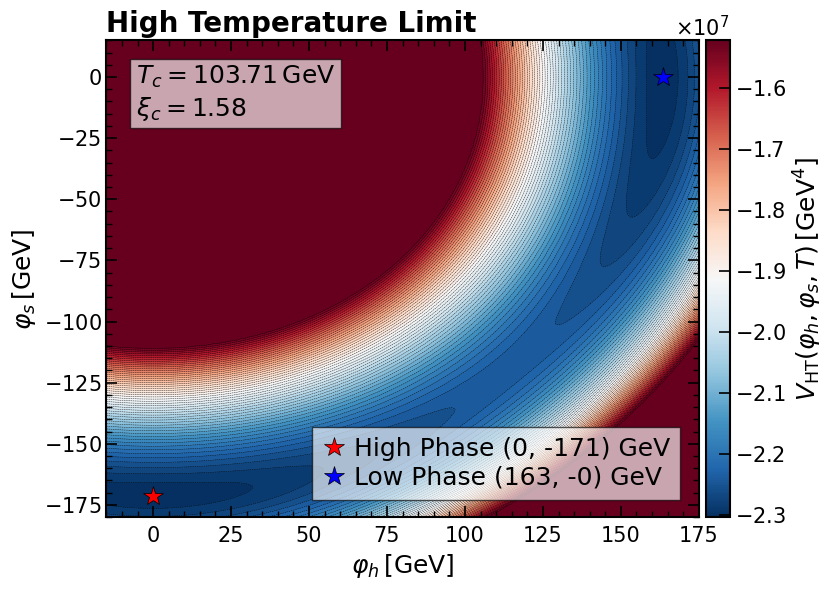

In [54]:
plot_effective_potential_HT(
    params_2step, Tc2,
    high=(0.0, -wTc2),
    low=(vTc2, 0.0),
    xi_c=vTc2/Tc2,
    h_range=(-15, 175), s_range=(-180, 15),
    outname="Figures/Tc_Contour_HT_2step.pdf"
)

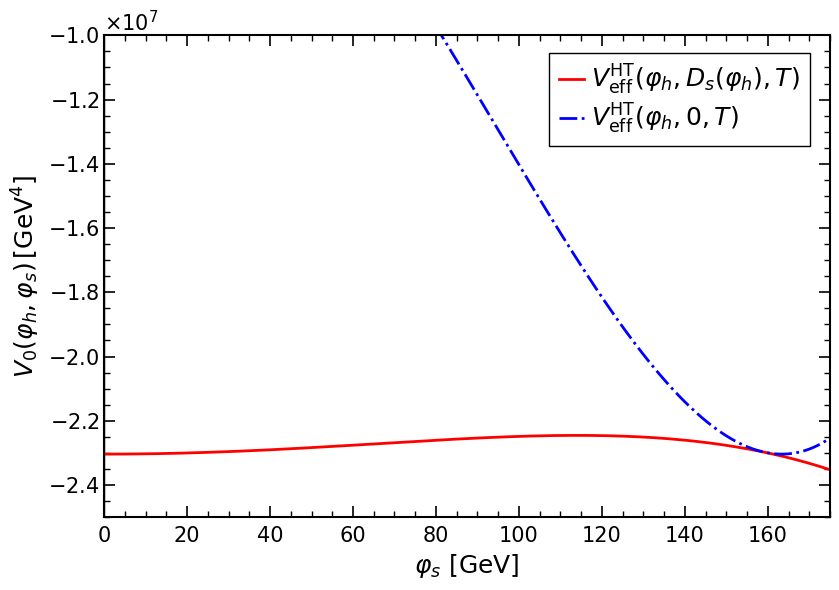

In [90]:
h = np.linspace(-50, 300, 1000)
V, h0 = Vpath_Z2(h, Tc2, params_2step)
V0 = V0_Z2(h, Tc2, params_2step)

# Create the plot
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(h, V, label=r'$V_{\mathrm{eff}}^{\mathrm{HT}}\left(\varphi_h,D_s(\varphi_h),T\right)$', color='r', lw=2, ls='-')
ax.plot(h, V0, label=r'$V_{\mathrm{eff}}^{\mathrm{HT}}\left(\varphi_h,0,T\right)$', color='b', lw=2, ls='-.')

ax.set_xlim(0, 175)
ax.set_ylim(-2.5e7, -1e7)

ax.set_xlabel(r'$\varphi_s$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_{0}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "upper right", bbox_to_anchor=(0.99, 0.99),
               ncol = 1, edgecolor="black", framealpha=1, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.tight_layout()
plt.savefig(f"Figures/TL_Path_HT_2step.pdf", format="pdf", bbox_inches="tight")
plt.show()

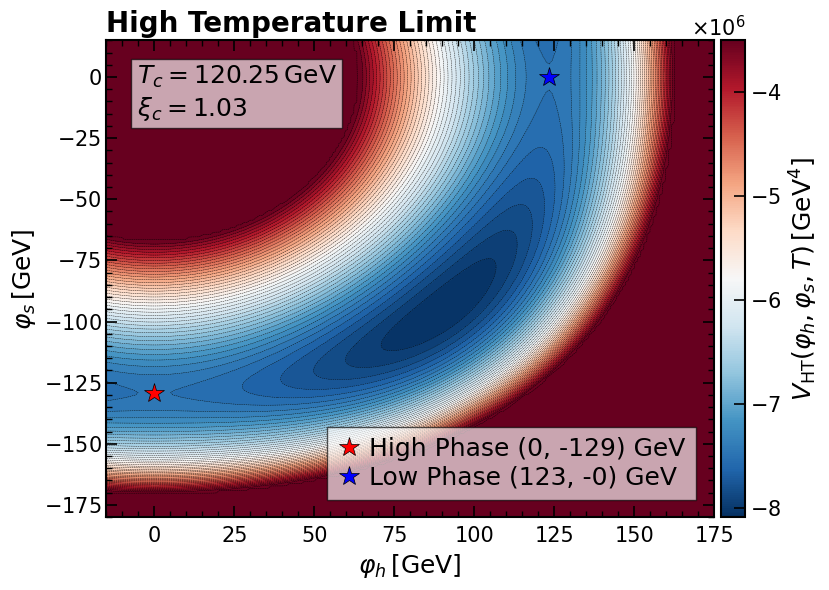

In [71]:
plot_effective_potential_HT(
    params_3step, Tc3,
    high=(0.0, -wTc3),
    low=(vTc3, 0.0),
    xi_c=vTc3/Tc3,
    h_range=(-15, 175), s_range=(-180, 15),
    outname="Figures/Tc_Contour_HT_3step.pdf"
)

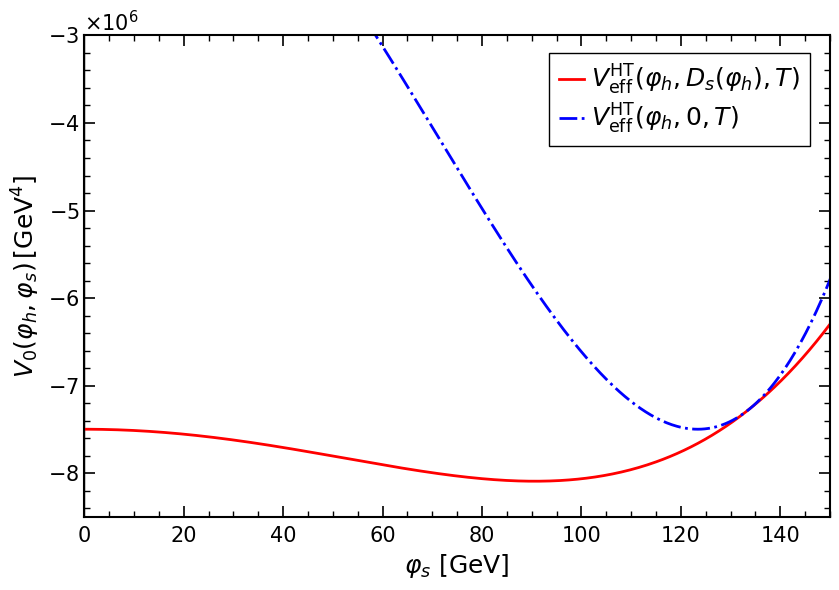

In [91]:
h = np.linspace(-50, 300, 1000)
V, h0 = Vpath_Z2(h, Tc3, params_3step)
V0 = V0_Z2(h, Tc3, params_3step)

# Create the plot
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(h, V, label=r'$V_{\mathrm{eff}}^{\mathrm{HT}}\left(\varphi_h,D_s(\varphi_h),T\right)$', color='r', lw=2, ls='-')
ax.plot(h, V0, label=r'$V_{\mathrm{eff}}^{\mathrm{HT}}\left(\varphi_h,0,T\right)$', color='b', lw=2, ls='-.')

ax.set_xlim(0, 150)
ax.set_ylim(-8.5e6, -3e6)

ax.set_xlabel(r'$\varphi_s$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_{0}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "upper right", bbox_to_anchor=(0.99, 0.99),
               ncol = 1, edgecolor="black", framealpha=1, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.tight_layout()
plt.savefig(f"Figures/TL_Path_HT_3step.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [99]:
params = create_params(10.0, 0.0, 0.037649, 0.002580,0.0)
Tc, v0, w0 = Z2_results(params, 0)
_, vTc, wTc  = Z2_results(params, Tc)

print(f'Tc={Tc:.4f} GeV | Xic={vTc/Tc:.4f}')

Tc=36.5237 GeV | Xic=6.5084


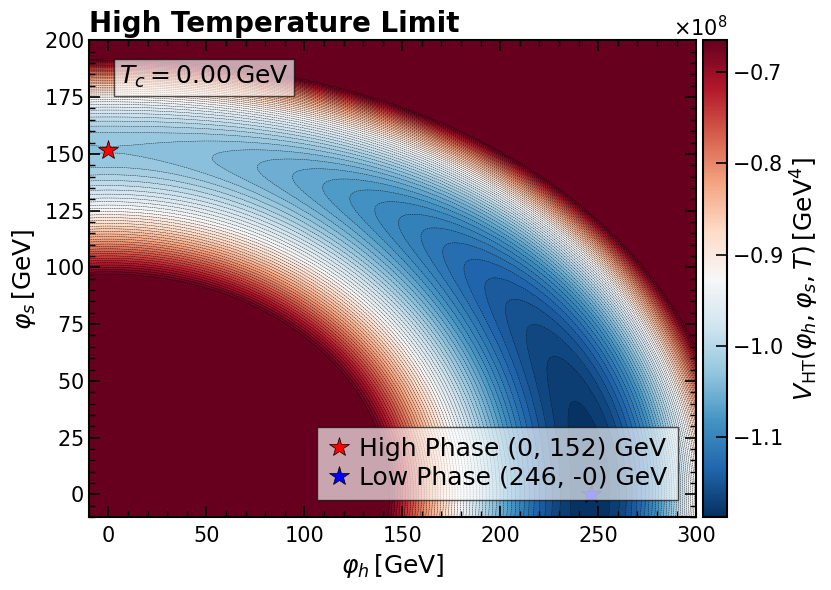

In [60]:
plot_effective_potential_HT(
    params, 0,
    high=(0.0, w0),
    low=(v0, 0.0),
    h_range=(-10, 300), s_range=(-10, 200),
    outname="Figures/Tl_Contour_Test.pdf"
)

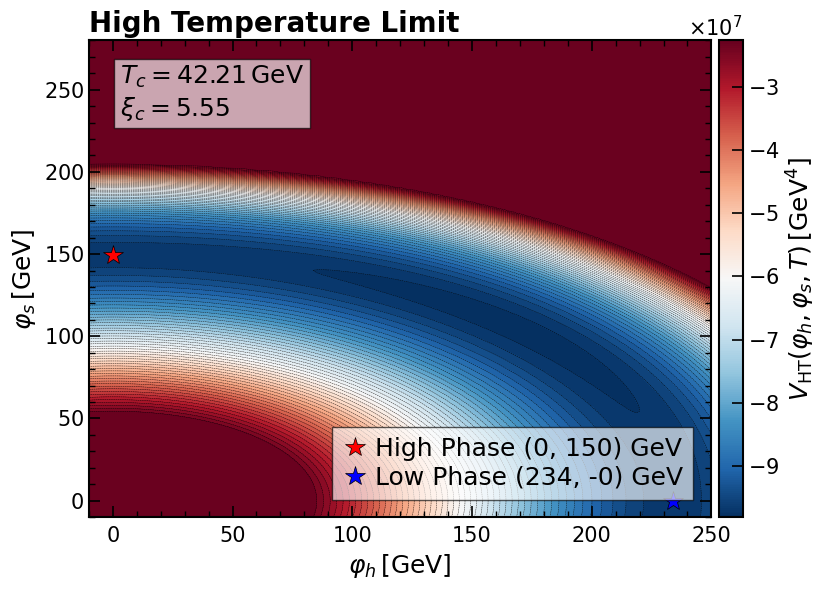

In [61]:
plot_effective_potential_HT(
    params, Tc,
    high=(0.0, wTc),
    low=(vTc, 0.0),
    xi_c=vTc/Tc,
    h_range=(-10, 250), s_range=(-10, 280),
    outname="Figures/Tc_Contour_Test.pdf"
)

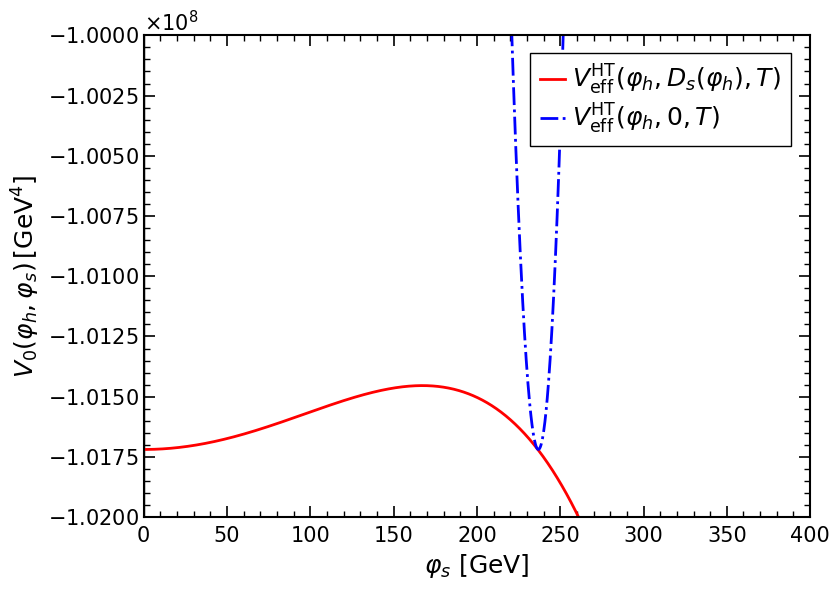

In [115]:
h = np.linspace(-50, 300, 1000)
V, h0 = Vpath_Z2(h, Tc, params)
V0 = V0_Z2(h, Tc, params)

# Create the plot
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(h, V, label=r'$V_{\mathrm{eff}}^{\mathrm{HT}}\left(\varphi_h,D_s(\varphi_h),T\right)$', color='r', lw=2, ls='-')
ax.plot(h, V0, label=r'$V_{\mathrm{eff}}^{\mathrm{HT}}\left(\varphi_h,0,T\right)$', color='b', lw=2, ls='-.')

ax.set_xlim(0, 400)
ax.set_ylim(-1.02e8, -1e8)

ax.set_xlabel(r'$\varphi_s$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_{0}(\varphi_h,\varphi_s) \, [\mathrm{GeV^4}]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=6.7)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "upper right", bbox_to_anchor=(0.99, 0.99),
               ncol = 1, edgecolor="black", framealpha=1, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.tight_layout()
plt.savefig(f"Figures/TL_Path_HT_test.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Analytical Scan

### $Z_2$ Symmetric Model

In [190]:
# Fixed Inputs
m1, v   = 125.2, 246.22
th, mu3 = 0.0, 0.0
g  = 0.6528226789050443
gp = 0.34994875330215097
yb = 0.024025892825142788
yt = 0.9902137038141565

# Create the grid
lHS = np.geomspace(1e-3, 1, 50)
lS  = np.geomspace(1e-6,  1,  50)
m2  = np.linspace(5,  m1/2,  50)
LHS, LS, M2 = np.meshgrid(lHS, lS, m2, indexing='ij')

# Lagrangian Parameters
p = physical_to_lagrangian(m1=m1, m2=M2, theta=th, v=v, lHS=LHS, lS=LS, mu3=mu3)
lH, muH2, muS2 = p['lH'], p['muH2'], p['muS2']

# Thermal Coefficients
cH = (9*g**2 + 3*gp**2 + 12*yb**2 + 12*yt**2 + 24*lH + 2*LHS) / 48
cS = LS/4 + LHS/6

# Transition Temperatures
T0h2 = muH2 / cH
T0s2 = muS2 / cS
Tc2 = (-np.sqrt(LS)*muH2 + np.sqrt(lH)*muS2) / (cS*np.sqrt(lH) - cH*np.sqrt(LS))

# VEVs
vTc2 = (muH2 - cH*Tc2) / lH
wTc2 = (muS2 - cS*Tc2) / LS

# Validity Mask
valid = (
    (muS2 > 0) & (LS > 0) & (Tc2 > 0) 
    & (Tc2 < T0h2) & (Tc2 < T0s2) & (T0s2 > T0h2) 
    & (LHS > 2*np.sqrt(lH*LS)) & (LS > (LHS*v**2 - 2*M2**2)**2 / (2*v**2*m1**2))
)

# Save only relevant data
idx = np.where(valid)
results = dict(
    lHS=LHS[idx], lS=LS[idx], m2=M2[idx],
    Tc=np.sqrt(Tc2[idx]),
    vTc=np.sqrt(vTc2[idx]),
    wTc=np.sqrt(wTc2[idx]),
    xic=np.sqrt(vTc2[idx])/np.sqrt(Tc2[idx])
)

results_df = pd.DataFrame(results)

In [191]:
results_df.Tc

0       132.524776
1       133.753471
2       134.768270
3       114.121414
4       118.579595
           ...    
3161     52.881520
3162     54.449258
3163     56.003305
3164     57.544771
3165     59.074641
Name: Tc, Length: 3166, dtype: float64

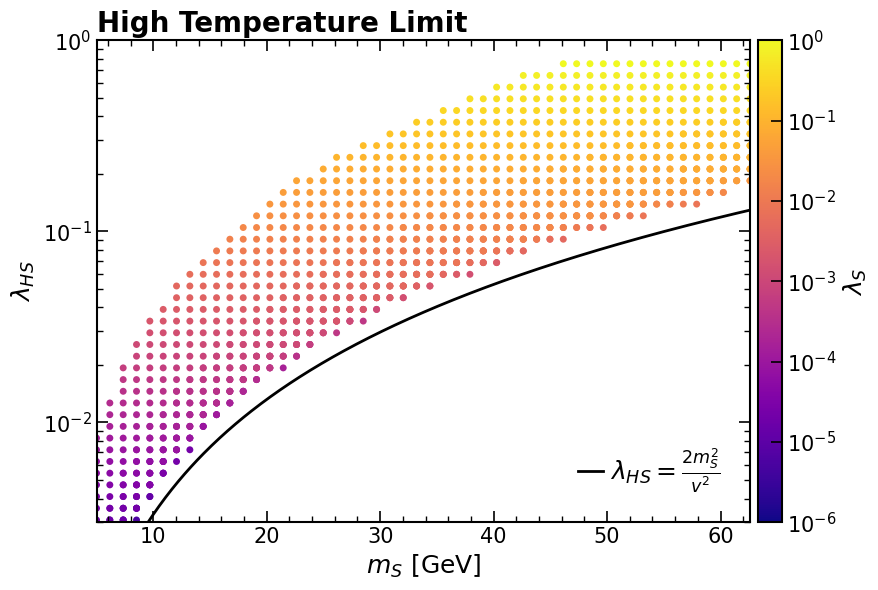

In [198]:
df = results_df[(results_df.xic>1)&(results_df.Tc>30)&(results_df.lS>(results_df.lHS*(results_df.lHS*v**2-2*results_df.m2**2))/(2*m1**2))]

# lHS curve
mS = np.linspace(0,70, 500)
a2 = 2*mS**2/246.22**2

cmap = plt.cm.plasma
norm = LogNorm(vmin=df['lS'].min(), vmax=df['lS'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['m2'], df['lHS'], c=df['lS'], cmap=cmap, norm=norm,
                 s=25, alpha=1, edgecolors='None')
ax.plot(mS, a2, label=r'$\lambda_{HS}=\frac{2m_S^2}{v^2}$', ls='-', c='k', lw=2)

ax.set_xlabel(r'$m_S \ [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')


ax.set_xlim(5, m1/2)
ax.set_ylim(3e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$\lambda_S$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

# Log-scale colorbar ticks
cbar.ax.yaxis.set_major_locator(LogLocator(base=10))
cbar.ax.yaxis.set_major_formatter(LogFormatterSciNotation())
cbar.ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1))

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)
cbar.ax.minorticks_off()

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"High Temperature Limit", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("Figures/Analytic_m2-lHS.pdf", format="pdf", bbox_inches="tight")
plt.show()


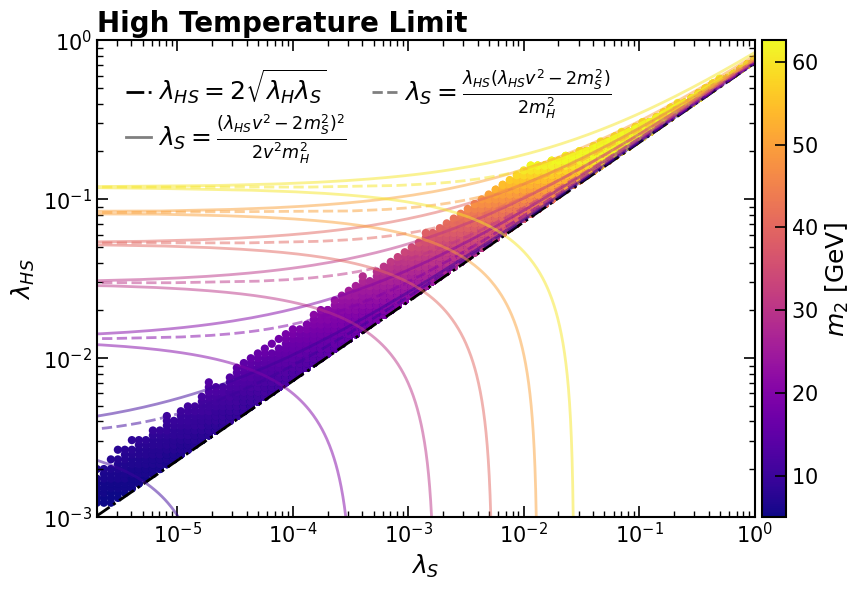

In [107]:
df = results_df[(results_df.xic>1)&(results_df.lS>(results_df.lHS*(results_df.lHS*v**2-2*results_df.m2**2))/(2*m1**2))]

cmap = plt.cm.plasma
norm = Normalize(vmin=df['m2'].min(), vmax=df['m2'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))


# SM values (adjust if you're using different fixed values)
m1 = 125.20  # GeV
v0 = 246.22   # GeV
lH = 0.5*m1**2/v0**2

def lS_min(lHS, m2):
    return (lHS * v0**2 - 2 * m2**2)**2 / (2 * v0**2 * m1**2)

def lS_JM(lHS, m2):
    return (lHS * (lHS*v0**2 - 2 * m2**2)) / (2 * m1**2)

lHS_vals = np.geomspace(1e-3, 1e0, 300)
LSCrit   = lHS_vals**2/(4*lH)
ax.plot(LSCrit, lHS_vals, c='k', lw=2, ls='-.')

m2_lines = [10, 20, 30, 40, 50, 60]

for m2_i in m2_lines:
    lS_curve = lS_min(lHS_vals, m2_i)
    lSJM_curve = lS_JM(lHS_vals, m2_i)
    ax.plot(lS_curve, lHS_vals, color=cmap(norm(m2_i)), alpha=0.5, linewidth=2)
    ax.plot(lSJM_curve, lHS_vals, color=cmap(norm(m2_i)), alpha=0.5, linewidth=2, ls='--')

sc = ax.scatter(df['lS'], df['lHS'], c=df['m2'], cmap=cmap, norm=norm,
                 s=35, alpha=1, edgecolors='None')

ax.set_xlabel(r'$\lambda_S$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlim(2e-6, 1e0)
ax.set_ylim(1e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$m_2\ [\mathrm{GeV}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

fmt = ScalarFormatter(useMathText=True)
fmt.set_powerlimits((-2, 3))
cbar.ax.yaxis.set_major_formatter(fmt)
cbar.ax.yaxis.get_offset_text().set_fontsize(15)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

handles_list = [mlines.Line2D([], [], color='k', linestyle='-.', linewidth=2, alpha=1, label=r"$\lambda_{HS}=2\sqrt{\lambda_H \lambda_S}$"),
                mlines.Line2D([], [], color='k', linestyle='-', linewidth=2, alpha=0.5, label=r"$\lambda_S=\frac{(\lambda_{HS}v^2 - 2m_S^2)^2}{2v^2m_H^2}$"),
                mlines.Line2D([], [], color='k', linestyle='--', linewidth=2, alpha=0.5, label=r"$\lambda_S=\frac{\lambda_{HS}(\lambda_{HS}v^2 - 2m_S^2)}{2m_H^2}$")]

plt.legend(handles=handles_list, fontsize=18, frameon=True, fancybox=False, loc = "upper left", bbox_to_anchor=(0.01, 0.99),
               ncol = 2, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"High Temperature Limit", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("Figures/Analytic_lS-lHS.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [114]:
results_df[(results_df.xic>1)&(results_df.lS>(results_df.lHS*(results_df.lHS*v**2-2*results_df.m2**2))/(2*m1**2))&(results_df.m2>9.9)&(results_df.m2<11)]

,lHS,lS,m2,Tc,vTc,wTc,xic
1165,0.004329,0.000008,10.236364,121.213964,124.217842,1395.706995,1.024782
1274,0.004642,0.000011,10.236364,111.641651,149.281542,1564.275907,1.337149
1279,0.004642,0.000012,10.236364,114.349484,142.837699,1445.435032,1.249133
1285,0.004642,0.000014,10.236364,116.735531,136.771866,1336.598551,1.171639
1292,0.004642,0.000016,10.236364,118.850547,131.049039,1236.763154,1.102637
...,...,...,...,...,...,...,...
7158,0.032745,0.001874,10.236364,36.400801,237.774008,685.276065,6.532109
7159,0.032745,0.001874,10.818182,40.200126,235.878396,679.812820,5.867603
7499,0.035112,0.002154,10.236364,34.027111,238.854232,664.787139,7.019527
7500,0.035112,0.002154,10.818182,37.807450,237.093549,659.886748,6.271080


In [109]:
df['Tc'].min()

np.float64(33.56598147131223)

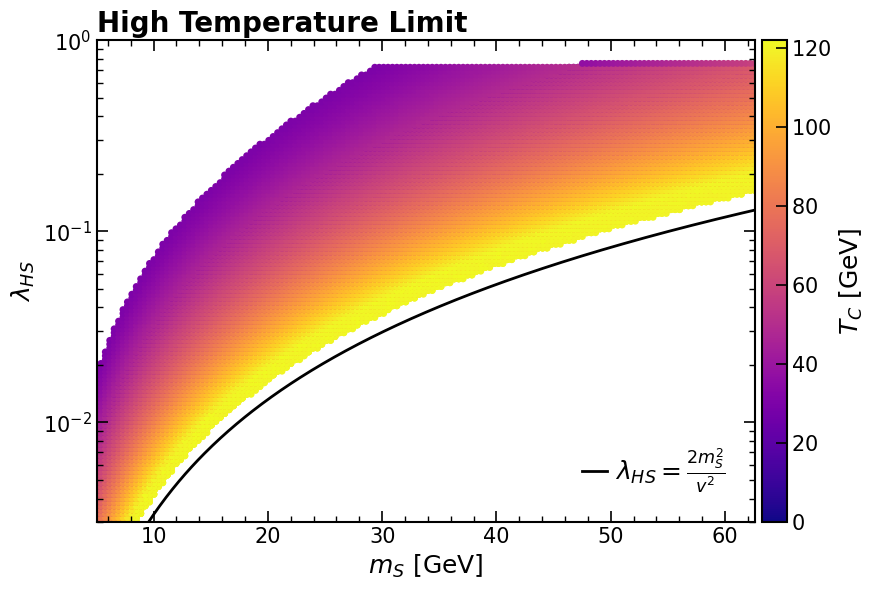

In [84]:
df = results_df[(results_df.xic>1)&(results_df.Tc>30)&(results_df.lS>(results_df.lHS*(results_df.lHS*v**2-2*results_df.m2**2))/(2*m1**2))]

# lHS curve
mS = np.linspace(0,70, 500)
a2 = 2*mS**2/246.22**2

cmap = plt.cm.plasma
norm = Normalize(vmin=0, vmax=df['Tc'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['m2'], df['lHS'], c=df['Tc'], cmap=cmap, norm=norm,
                 s=25, alpha=1, edgecolors='None')
ax.plot(mS, a2, label=r'$\lambda_{HS}=\frac{2m_S^2}{v^2}$', ls='-', c='k', lw=2)

ax.set_xlabel(r'$m_S \ [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')


ax.set_xlim(5, m1/2)
ax.set_ylim(3e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$T_C \ [\mathrm{GeV}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

# Log-scale colorbar ticks
fmt.set_powerlimits((-2, 3))
cbar.ax.yaxis.set_major_formatter(fmt)
cbar.ax.yaxis.get_offset_text().set_fontsize(15)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)
cbar.ax.minorticks_off()

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"High Temperature Limit", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("Figures/Analytic_m2-lHS_Tc.pdf", format="pdf", bbox_inches="tight")
plt.show()


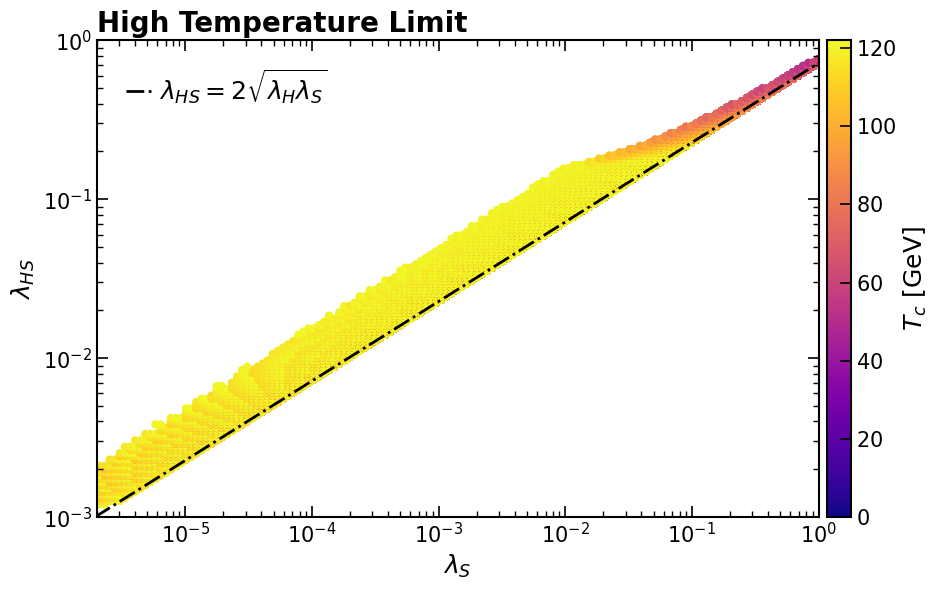

In [85]:
df = results_df[(results_df.xic>1)&(results_df.lS>(results_df.lHS*(results_df.lHS*v**2-2*results_df.m2**2))/(2*m1**2))]

cmap = plt.cm.plasma
norm = Normalize(vmin=0, vmax=df['Tc'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9.76, 6))


# SM values (adjust if you're using different fixed values)
m1 = 125.20  # GeV
v0 = 246.22   # GeV
lH = 0.5*m1**2/v0**2

def lS_min(lHS, m2):
    return (lHS * v0**2 - 2 * m2**2)**2 / (2 * v0**2 * m1**2)

def lS_JM(lHS, m2):
    return (lHS * (lHS*v0**2 - 2 * m2**2)) / (2 * m1**2)

lHS_vals = np.geomspace(1e-3, 1e0, 300)
LSCrit   = lHS_vals**2/(4*lH)
ax.plot(LSCrit, lHS_vals, c='k', lw=2, ls='-.')

m2_lines = [10, 20, 30, 40, 50, 60]

for m2_i in m2_lines:
    lS_curve = lS_min(lHS_vals, m2_i)
    lSJM_curve = lS_JM(lHS_vals, m2_i)
    #ax.plot(lS_curve, lHS_vals, color=cmap(norm(m2_i)), alpha=0.5, linewidth=2)
    #ax.plot(lSJM_curve, lHS_vals, color=cmap(norm(m2_i)), alpha=0.5, linewidth=2, ls='--')

sc = ax.scatter(df['lS'], df['lHS'], c=df['Tc'], cmap=cmap, norm=norm,
                 s=35, alpha=1, edgecolors='None')

ax.set_xlabel(r'$\lambda_S$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlim(2e-6, 1e0)
ax.set_ylim(1e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$T_c\ [\mathrm{GeV}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

fmt = ScalarFormatter(useMathText=True)
fmt.set_powerlimits((-2, 3))
cbar.ax.yaxis.set_major_formatter(fmt)
cbar.ax.yaxis.get_offset_text().set_fontsize(15)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

handles_list = [mlines.Line2D([], [], color='k', linestyle='-.', linewidth=2, alpha=1, label=r"$\lambda_{HS}=2\sqrt{\lambda_H \lambda_S}$")]
                #mlines.Line2D([], [], color='k', linestyle='-', linewidth=2, alpha=0.5, label=r"$\lambda_S=\frac{(\lambda_{HS}v^2 - 2m_S^2)^2}{2v^2m_H^2}$"),
                #mlines.Line2D([], [], color='k', linestyle='--', linewidth=2, alpha=0.5, label=r"$\lambda_S=\frac{\lambda_{HS}(\lambda_{HS}v^2 - 2m_S^2)}{2m_H^2}$")]

plt.legend(handles=handles_list, fontsize=18, frameon=True, fancybox=False, loc = "upper left", bbox_to_anchor=(0.01, 0.99),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"High Temperature Limit", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("Figures/Analytic_lS-lHS_Tc.pdf", format="pdf", bbox_inches="tight")
plt.show()

### General Model

#### Test

In [41]:
# Fixed Inputs
m1, v   = 125.2, 246.22
g  = 0.6528226789050443
gp = 0.34994875330215097
yb = 0.024025892825142788
yt = 0.9902137038141565

# Test Parameters
m2  = 20
th  = 0.0
lHS = 1e-1
lS  = 1e-1
mu3 = 0

# Lagrangian Parameter
params = physical_to_lagrangian(
    m1    = m1,
    m2    = m2,
    theta = th,
    v     = v,
    lHS   = lHS,
    lS    = lS,
    mu3   = mu3
)

lH   = params["lH"]
lHS  = params["lHS"]
muHS = params["muHS"]
lS   = params["lS"]
mu3  = params["mu3"]
muH2 = params["muH2"]
muS2 = params["muS2"]
mu13 = params["mu13"]

# Thermal Coeficients
cH = (9*g**2 + 3*gp**2 + 12*yb**2 + 12*yt**2 + 24*lH + 2*lHS) / 48
cS = lS/4 + lHS/6
c1 = (-mu3 + 2*muHS)/12

# Find Symmetric Minima
def find_w(T):
    a = lS
    b = -mu3
    c = cS*T**2 - muS2
    d = c1*T**2 + mu13
    X = np.roots([a,b,c,d])
    RealX = X[np.abs(X.imag) < 1e-8].real
    d2V   = cS*T**2 - muS2 - 2*mu3*RealX + 3*lS*RealX**2
    candidatews = RealX[d2V>0]
    return candidatews

# Find ElectroWeak Minima
def find_EW(T):
    Tew = np.sqrt(muH2/cH) # Safety check on high temerature
    if T>Tew:
        return [0], [0]
    sp = (-muHS+(-2*cH*lHS*T**2+2*lHS*muH2+muHS**2)**0.5)/(lHS)
    sm = (-muHS-(-2*cH*lHS*T**2+2*lHS*muH2+muHS**2)**0.5)/(lHS)

    a = lS - (lHS**2)/(4*lH)
    b = -mu3 - (3*lHS*muHS)/(4*lH)
    c = (cS-(cH*lHS)/(2*lH))*T**2 + (lHS*muH2)/(2*lH) - (muHS**2)/(2*lH) - muS2
    d = mu13 + (muH2*muHS)/(2*lH) + (c1-(cH*muHS)/(2*lH))*T**2
    X = np.roots([a,b,c,d])
    RealX = X[np.abs(X.imag) < 1e-8].real
    validX = RealX[(sm < RealX) & (RealX < sp)]
    d2V = (cS-(cH*lHS)/(2*lH))*T**2 + (lHS*muH2)/(2*lH) - (muHS**2)/(2*lH) - muS2 - (2*mu3 - (3*lHS*muHS)/(2*lH))*validX + (2*lS - (lHS**2)/(2*lH))*validX**2
    candidatesvs = validX[d2V > 0]
    candidatesvh = np.sqrt((2*muH2 - 2*cH*T**2 - 2*muHS*candidatesvs - lHS*candidatesvs**2)/(2*lH))
    return candidatesvh,candidatesvs

# Select the true Symmetric Minima
def global_symmetric_min(T):
    ws = find_w(T)
    if len(ws) == 0:
        return np.nan, np.nan
    Vs = VHT(0.0, ws, T)
    i = np.argmin(Vs)
    return ws[i], Vs[i]

# Select the true EW Minima
def global_EW_min(T):
    vh, vs = find_EW(T)
    vh = np.asarray(vh, dtype=float)
    vs = np.asarray(vs, dtype=float)
    if len(vh) == 0:
        return np.nan, np.nan, np.nan
    Vs = VHT(vh, vs, T)
    i = np.argmin(Vs)
    return vh[i], vs[i], Vs[i]

# High Temperature Potential
def VHT(h,s,T):
    V = (cH*T**2-muH2)*(h**2)/(2) + lH*(h**4)/(4) + (c1*T**2+mu13)*s + (cS*T**2-muS2)*(s**2)/(2) - mu3*(s**3)/(3) + lS*(s**4)/(4) + 0.5*muHS*s*h**2 + 0.25*lHS*s**2*h**2
    return V 

# Delta Function
def delta_V(T):
    _, V_sym = global_symmetric_min(T)
    _, _, V_ew = global_EW_min(T)
    if np.isnan(V_sym) or np.isnan(V_ew):
        return np.nan
    return V_ew - V_sym

def find_Tc(Tmin=1e-3, Tmax=300, nscan=200):
    Ts = np.linspace(Tmin, Tmax, nscan)
    dV = np.array([delta_V(T) for T in Ts])
    valid = np.isfinite(dV)
    Ts, dV = Ts[valid], dV[valid]
    sign_changes = np.where(np.diff(np.sign(dV)) != 0)[0]

    if len(sign_changes) == 0:
        return None

    roots = []
    for idx in sign_changes:
        a, b = Ts[idx], Ts[idx+1]
        try:
            Tc = brentq(delta_V, a, b, xtol=1e-10, rtol=1e-12)
            if Tc < np.sqrt(muH2/cH):
                roots.append(Tc)
            else:
                continue
        except ValueError:
            continue

    return roots

from time import perf_counter

start = perf_counter()

# --- Strength of the transition ---
Tc = find_Tc()[0]
vh_c, vs_c, Vew = global_EW_min(Tc)
strength = vh_c / Tc

end = perf_counter()

print(f"Tc = {Tc:.4f} GeV")
print(f"v(Tc) = {vh_c:.4f} GeV, u(Tc) = {vs_c:.4f} GeV, V(v,u,Tc) = {Vew} GeV^4")
print(f"xic = v(Tc)/Tc = {strength:.4f}")

print(f"Elapsed time = {end-start:.6f} s")

IndexError: list index out of range

#### Scan

##### Functions

In [3]:
def create_params(m2, th, lHS, lS, mu3):
    # Fixed Inputs
    m1, v   = 125.2, 246.22
    g  = 0.6528226789050443
    gp = 0.34994875330215097
    yb = 0.024025892825142788
    yt = 0.9902137038141565

    p = physical_to_lagrangian(m1, m2, th, v, lHS, lS, mu3)
    muH2, lH, mu13, muHS, muS2 = p['muH2'], p['lH'], p['mu13'], p['muHS'], p['muS2']

    cH = (9*g**2 + 3*gp**2 + 12*yb**2 + 12*yt**2 + 24*lH + 2*lHS) / 48
    cS = lS/4 + lHS/6
    c1 = (-mu3 + 2*muHS)/12

    return{
        "lH": lH, "lHS": lHS, "muHS": muHS, "lS": lS,
        "mu3": mu3, "muH2": muH2, "muS2": muS2, "mu13": mu13,
        "cH": cH, "cS": cS, "c1": c1
    }

def cubic_real_roots_vec(a, b, c, d, tol=1e-10):
    """
    Finds real roots of ax^3 + bx^2 + cx + d = 0 for vectorized NumPy arrays.
    Returns an array of shape (..., 3) padded with NaNs where fewer than 3 roots exist.
    """
    a, b, c, d = np.broadcast_arrays(a, b, c, d)
    a, b, c, d = a.astype(float), b.astype(float), c.astype(float), d.astype(float)
    
    # Depress the cubic: t^3 + pt + q = 0
    b_a, c_a, d_a = b / a, c / a, d / a
    shift = b_a / 3.0
    p = c_a - b_a**2 / 3.0
    q = 2.0 * b_a**3 / 27.0 - b_a * c_a / 3.0 + d_a
    disc = -4.0 * p**3 - 27.0 * q**2
    
    roots = np.full(a.shape + (3,), np.nan)
    three = disc > tol
    one = ~three  # Covers disc <= tol safely

    # --- 3 Real Roots (Viète's Method) ---
    if np.any(three):
        pp, qq = p[three], q[three]
        r = np.sqrt(-pp / 3.0)
        arg = np.clip((3.0 * qq) / (2.0 * pp * r), -1.0, 1.0)
        phi = np.arccos(arg)
        
        k = np.arange(3)
        angles = phi[..., None] / 3.0 - (2.0 * np.pi * k) / 3.0
        roots[three] = 2.0 * r[..., None] * np.cos(angles) - shift[three, ..., None]

    # --- 1 Real Root (Cardano's Method) ---
    if np.any(one):
        pp, qq = p[one], q[one]
        sq = np.sqrt(np.maximum(qq**2 / 4.0 + pp**3 / 27.0, 0.0))
        cbrt = lambda x: np.sign(x) * np.abs(x)**(1.0 / 3.0)
        roots[one, 0] = cbrt(-qq / 2.0 + sq) + cbrt(-qq / 2.0 - sq) - shift[one]

    return roots

def find_w_vec(T_list, params, pointwise=False):
    # (N,1) pointwise / (1,M) grid
    T = T_list[:, None] if pointwise else T_list[None, :]                         
    # (N, 1)
    lS   = params["lS"][:, None]                  
    mu3  = params["mu3"][:, None]
    muS2 = params["muS2"][:, None]
    mu13 = params["mu13"][:, None]
    cS = params["cS"][:, None]                 
    c1   = params["c1"][:, None]

    # Compute the Roots
    dSy = c1*T**2 + mu13
    cSy = cS*T**2 - muS2
    bSy = np.broadcast_to(-mu3, dSy.shape)
    aSy = np.broadcast_to(lS, dSy.shape)
    roots_S = cubic_real_roots_vec(aSy, bSy, cSy, dSy)

    d2V_S = cSy[..., None] + 2*bSy[..., None]*roots_S + 3*aSy[..., None]*roots_S**2
    valid_S = (d2V_S > 0) & ~np.isnan(roots_S)
    w = np.where(valid_S, roots_S, np.nan)    
    return w

def find_EW_vec(T_list, params, pointwise=False):
    # (N,1) pointwise / (1,M) grid
    T = T_list[:, None] if pointwise else T_list[None, :] 
    lH   = params["lH"][:, None]
    lHS  = params["lHS"][:, None]
    muHS = params["muHS"][:, None]
    muH2 = params["muH2"][:, None]
    muS2 = params["muS2"][:, None]
    mu3  = params["mu3"][:, None]
    mu13 = params["mu13"][:, None]
    cH   = params["cH"][:, None]
    cS_p = params["cS"][:, None]
    c1   = params["c1"][:, None]

    Tew = np.sqrt(muH2 / cH)                                 # (N, 1)
    above = T > Tew                                           # (N, M)

    with np.errstate(invalid="ignore"):
        disc = -2*cH*lHS*T**2 + 2*lHS*muH2 + muHS**2
        rootdisc = np.sqrt(np.where(disc >= 0, disc, np.nan))
    sp = (-muHS + rootdisc) / lHS
    sm = (-muHS - rootdisc) / lHS

    aE = np.broadcast_to(lHS_a := (params["lS"][:, None] - lHS**2/(4*lH)),
                          (lH.shape[0], T.shape[-1]))
    bE = np.broadcast_to(-params["mu3"][:, None] - (3*lHS*muHS)/(4*lH), aE.shape)
    cE = (cS_p - (cH*lHS)/(2*lH))*T**2 + (lHS*muH2)/(2*lH) - (muHS**2)/(2*lH) - muS2
    dE = mu13 + (muH2*muHS)/(2*lH) + (c1 - (cH*muHS)/(2*lH))*T**2

    roots_E = cubic_real_roots_vec(aE, bE, cE, dE)            # (N, M, 3)

    inrange = (roots_E > sm[..., None]) & (roots_E < sp[..., None]) & ~np.isnan(roots_E)

    d2V_E = cE[..., None] + 2*bE[..., None]*roots_E + 3*aE[..., None]*roots_E**2
    valid_E = inrange & (d2V_E > 0)

    vs = np.where(valid_E, roots_E, np.nan)                   # (N, M, 3)

    with np.errstate(invalid="ignore"):
        vh2 = (2*muH2[..., None] - 2*cH[..., None]*T[..., None]**2
               - 2*muHS[..., None]*vs - lHS[..., None]*vs**2) / (2*lH[..., None])
    vh = np.sqrt(np.where(vh2 >= 0, vh2, np.nan))

    vh = np.where(above[..., None], np.nan, vh)
    vs = np.where(above[..., None], np.nan, vs)

    return vh, vs

def VHT_vec(h, s, T_list, params, pointwise=False):
    # (N,1) pointwise / (1,M) grid
    T = T_list[:, None, None] if pointwise else T_list[None, :, None] 
    cH   = params["cH"][:, None, None]
    muH2 = params["muH2"][:, None, None]
    lH   = params["lH"][:, None, None]
    c1   = params["c1"][:, None, None]
    mu13 = params["mu13"][:, None, None]
    cS   = params["cS"][:, None, None]
    muS2 = params["muS2"][:, None, None]
    mu3  = params["mu3"][:, None, None]
    lS   = params["lS"][:, None, None]
    muHS = params["muHS"][:, None, None]
    lHS  = params["lHS"][:, None, None]

    V = ((cH*T**2 - muH2)*(h**2)/2 + lH*(h**4)/4
         + (c1*T**2 + mu13)*s + (cS*T**2 - muS2)*(s**2)/2
         - mu3*(s**3)/3 + lS*(s**4)/4
         + 0.5*muHS*s*h**2 + 0.25*lHS*s**2*h**2)
    return V

def global_symmetric_min_vec(T_list, params, pointwise=False):
    w = find_w_vec(T_list, params, pointwise=pointwise)  
    Vs = VHT_vec(np.zeros_like(w), w, T_list, params, pointwise=pointwise)                            # (N, M, 3)
    all_nan = np.all(np.isnan(Vs), axis=-1)
    Vs_safe = np.where(np.isnan(Vs), np.inf, Vs)
    idx = np.argmin(Vs_safe, axis=-1)                           # (N, M)
    w_sel = np.take_along_axis(w, idx[..., None], axis=-1)[..., 0]
    V_sel = np.take_along_axis(Vs, idx[..., None], axis=-1)[..., 0]
    w_sel = np.where(all_nan, np.nan, w_sel)
    V_sel = np.where(all_nan, np.nan, V_sel)
    return w_sel, V_sel  

def global_EW_min_vec(T_list, params, pointwise=False):
    vh, vs = find_EW_vec(T_list, params, pointwise=pointwise)
    Vs = VHT_vec(vh, vs, T_list, params, pointwise=pointwise)
    all_nan = np.all(np.isnan(Vs), axis=-1)
    Vs_safe = np.where(np.isnan(Vs), np.inf, Vs)
    idx = np.argmin(Vs_safe, axis=-1)
    vh_sel = np.where(all_nan, np.nan, np.take_along_axis(vh, idx[..., None], axis=-1)[..., 0])
    vs_sel = np.where(all_nan, np.nan, np.take_along_axis(vs, idx[..., None], axis=-1)[..., 0])
    V_sel  = np.where(all_nan, np.nan, np.take_along_axis(Vs, idx[..., None], axis=-1)[..., 0])
    return vh_sel, vs_sel, V_sel

def delta_V_vec(T_list, params, pointwise=False):
    _, V_sym = global_symmetric_min_vec(T_list, params, pointwise=pointwise)
    _, _, V_ew = global_EW_min_vec(T_list, params, pointwise=pointwise)
    return V_ew - V_sym

def find_Tc_vec(params, Tmin=1e-3, Tmax=300, nscan=150, n_bisect=52):
    N = params["lH"].shape[0]
    T_list = np.linspace(Tmin, Tmax, nscan)              # (M,) — shared scan grid, M = nscan

    dV = delta_V_vec(T_list, params, pointwise=False)                      # (N, M): params 1D (N,), T 1D (M,) -> (N,M)

    s = np.sign(dV)
    finite_pair = np.isfinite(dV[:, :-1]) & np.isfinite(dV[:, 1:])
    change = (np.diff(s, axis=1) != 0) & finite_pair       # (N, M-1): True where consecutive columns flip sign

    Tew = np.sqrt(params["muH2"] / params["cH"])            # (N,)
    below_Tew = T_list[None, :-1] < Tew[:, None]             # (N, M-1): broadcast the 1D grid against each row's own Tew
    change = change & below_Tew

    has_root = change.any(axis=1)                            # (N,) — does row i have any valid crossing at all
    idx = np.argmax(change, axis=1)                           # (N,) — column index of first True per row

    lo = T_list[idx]                                            # (N,) — index the *shared* 1D grid with per-row indices
    hi = T_list[idx + 1]                                         # (N,)

    def dV_at(Tvec):
        return delta_V_vec(Tvec, params, pointwise=True)[:, 0]                                   

    sign_lo = np.sign(dV_at(lo))
    for _ in range(n_bisect):
        mid = 0.5 * (lo + hi)
        sign_mid = np.sign(dV_at(mid))
        go_right = sign_mid == sign_lo
        lo = np.where(go_right, mid, lo)
        hi = np.where(go_right, hi, mid)
        sign_lo = np.where(go_right, sign_mid, sign_lo)

    Tc = np.where(has_root, 0.5 * (lo + hi), np.nan)
    return Tc

##### Recreate the $Z_2$ Result

In [195]:
m1, v   = 125.2, 246.22
n = 50
# Create the grid
M2  = np.linspace(5.0, m1/2, n)
TH  = np.insert(np.geomspace(1e-2, 1e-1, 0), 0, 0.0)
LHS = np.geomspace(1e-3, 1, n)
LS  = np.geomspace(1e-6,  1,  n)
MU3 = np.insert(np.geomspace(1e-3*v, 1e-2*v, 0), 0, 0.0)
m2, th, lHS, lS, mu3 = np.meshgrid(M2, TH, LHS, LS, MU3, indexing='ij')
# Vectorize the parameters
m2, th, lHS, lS, mu3 = m2.ravel(), th.ravel(), lHS.ravel(), lS.ravel(), mu3.ravel()
params = create_params(m2, th, lHS, lS, mu3)

start = perf_counter()

Tc = find_Tc_vec(params)
vh, _, _ = global_EW_min_vec(Tc,params,pointwise=True)
vh = vh[:, 0] 
xic = vh / Tc   

end = perf_counter()
print(f"Elapsed time = {end-start:.6f} s")

Elapsed time = 26.883785 s


In [ ]:
data = {'m2':m2, 'th':th, 'lHS':lHS, 'lS':lS, 'mu3':mu3, 'Tc':Tc, 'xic':xic}
Results_df = pd.DataFrame(data).dropna(subset=["Tc"])

,m2,th,lHS,lS,mu3,Tc,xic
0,5.0,0.0,0.001000,0.000001,0.0,132.524776,0.613995
1,5.0,0.0,0.001000,0.000001,0.0,133.753471,0.560234
2,5.0,0.0,0.001000,0.000002,0.0,134.768270,0.512855
50,5.0,0.0,0.001151,0.000001,0.0,114.121414,1.256984
51,5.0,0.0,0.001151,0.000001,0.0,118.579595,1.112012
...,...,...,...,...,...,...,...
124796,62.6,0.0,0.568987,0.429193,0.0,41.035839,5.722196
124797,62.6,0.0,0.568987,0.568987,0.0,69.399888,3.054386
124847,62.6,0.0,0.655129,0.568987,0.0,28.034198,8.593758
124848,62.6,0.0,0.655129,0.754312,0.0,64.096477,3.386833


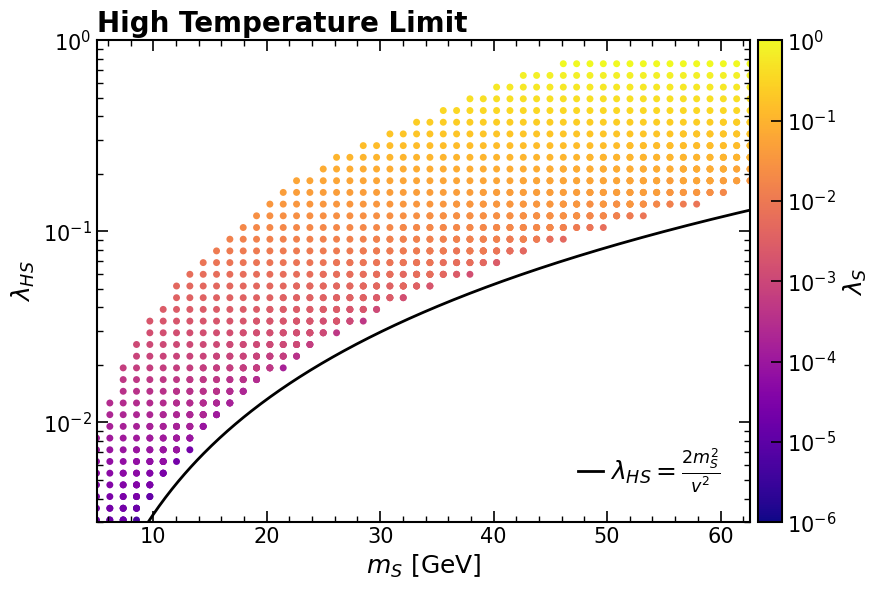

In [205]:
df = Results_df[(Results_df.xic>1)&(Results_df.Tc>30)&(Results_df.lS>(Results_df.lHS*(Results_df.lHS*v**2-2*Results_df.m2**2))/(2*m1**2))]

# lHS curve
mS = np.linspace(0,70, 500)
a2 = 2*mS**2/246.22**2

cmap = plt.cm.plasma
norm = LogNorm(vmin=df['lS'].min(), vmax=df['lS'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['m2'], df['lHS'], c=df['lS'], cmap=cmap, norm=norm,
                 s=25, alpha=1, edgecolors='None')
ax.plot(mS, a2, label=r'$\lambda_{HS}=\frac{2m_S^2}{v^2}$', ls='-', c='k', lw=2)

ax.set_xlabel(r'$m_S \ [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')


ax.set_xlim(5, m1/2)
ax.set_ylim(3e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$\lambda_S$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

# Log-scale colorbar ticks
cbar.ax.yaxis.set_major_locator(LogLocator(base=10))
cbar.ax.yaxis.set_major_formatter(LogFormatterSciNotation())
cbar.ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1))

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)
cbar.ax.minorticks_off()

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"High Temperature Limit", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("Figures/Analytic_m2-lHS.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Results of Scan

In [104]:
Df = pd.read_csv('Z2_Scan_Tn.csv')

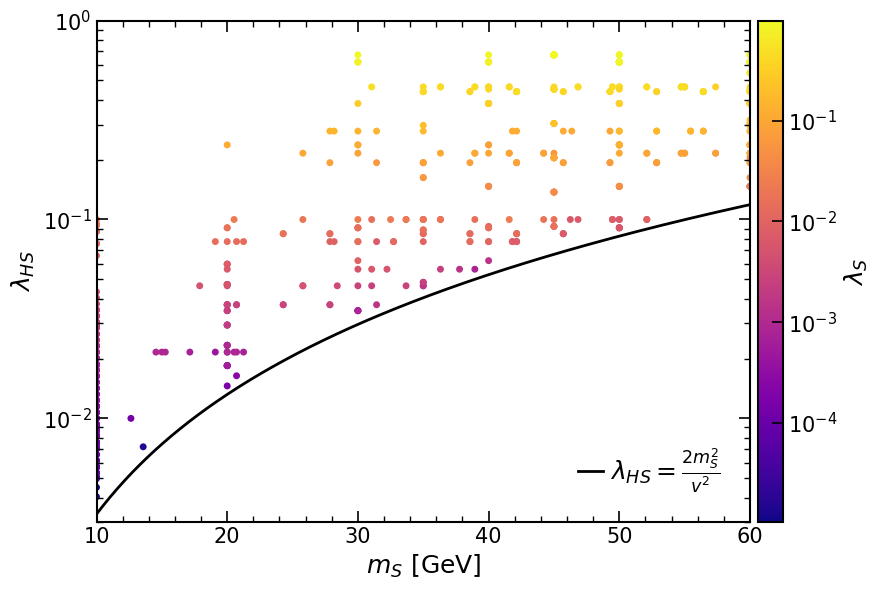

In [105]:
df = Df[(Df.status=='Nucleation_FOPT')]

# lHS curve
mS = np.linspace(0,70, 500)
a2 = 2*mS**2/246.22**2

cmap = plt.cm.plasma
norm = LogNorm(vmin=df['lS'].min(), vmax=df['lS'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(df['m2'], df['lHS'], c=df['lS'], cmap=cmap, norm=norm,
                 s=25, alpha=1, edgecolors='None')
ax.plot(mS, a2, label=r'$\lambda_{HS}=\frac{2m_S^2}{v^2}$', ls='-', c='k', lw=2)

ax.set_xlabel(r'$m_S \ [\mathrm{GeV}]$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')


ax.set_xlim(10, 60)
ax.set_ylim(3e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$\lambda_S$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

# Log-scale colorbar ticks
cbar.ax.yaxis.set_major_locator(LogLocator(base=10))
cbar.ax.yaxis.set_major_formatter(LogFormatterSciNotation())
cbar.ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)*0.1))

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)
cbar.ax.minorticks_off()

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower right", bbox_to_anchor=(0.99, 0.01),
               ncol = 1, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

#plt.title(r"$\mathbb{Z}_2$ limit. $\exists T_n$", loc='left', fontsize=20)
plt.tight_layout()
plt.savefig("Figures/Scan_m2-lHS_nucleation.pdf", format="pdf", bbox_inches="tight")
plt.show()


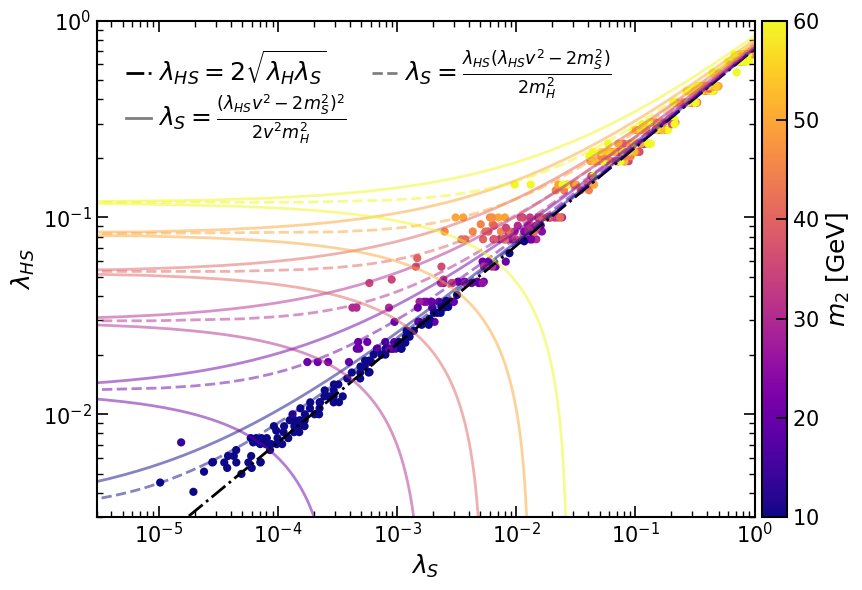

In [7]:
df = Df[(Df.status=='Nucleation_FOPT')&(Df.xic>1)]

cmap = plt.cm.plasma
norm = Normalize(vmin=df['m2'].min(), vmax=df['m2'].max())
sm   = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9, 6))


# SM values (adjust if you're using different fixed values)
m1 = 125.20  # GeV
v0 = 246.22   # GeV
lH = 0.5*m1**2/v0**2

def lS_min(lHS, m2):
    return (lHS * v0**2 - 2 * m2**2)**2 / (2 * v0**2 * m1**2)

def lS_JM(lHS, m2):
    return (lHS * (lHS*v0**2 - 2 * m2**2)) / (2 * m1**2)

lHS_vals = np.geomspace(1e-3, 1e0, 300)
LSCrit   = lHS_vals**2/(4*lH)
ax.plot(LSCrit, lHS_vals, c='k', lw=2, ls='-.')

m2_lines = [10, 20, 30, 40, 50, 60]

for m2_i in m2_lines:
    lS_curve = lS_min(lHS_vals, m2_i)
    lSJM_curve = lS_JM(lHS_vals, m2_i)
    ax.plot(lS_curve, lHS_vals, color=cmap(norm(m2_i)), alpha=0.5, linewidth=2)
    ax.plot(lSJM_curve, lHS_vals, color=cmap(norm(m2_i)), alpha=0.5, linewidth=2, ls='--')

sc = ax.scatter(df['lS'], df['lHS'], c=df['m2'], cmap=cmap, norm=norm,
                 s=35, alpha=1, edgecolors='None')

ax.set_xlabel(r'$\lambda_S$', fontsize=18)
ax.set_ylabel(r'$\lambda_{HS}$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.set_yscale('log')
ax.set_xscale('log')

ax.set_xlim(3e-6, 1e0)
ax.set_ylim(3e-3, 1e0)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in',
               length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$m_2\ [\mathrm{GeV}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)

fmt = ScalarFormatter(useMathText=True)
fmt.set_powerlimits((-2, 3))
cbar.ax.yaxis.set_major_formatter(fmt)
cbar.ax.yaxis.get_offset_text().set_fontsize(15)

for spine in cbar.ax.spines.values():
    spine.set_linewidth(1.5)
cbar.ax.tick_params(axis='both', which='major', direction='in',
               length=8, width=1.2, labelsize=15)

handles_list = [mlines.Line2D([], [], color='k', linestyle='-.', linewidth=2, alpha=1, label=r"$\lambda_{HS}=2\sqrt{\lambda_H \lambda_S}$"),
                mlines.Line2D([], [], color='k', linestyle='-', linewidth=2, alpha=0.5, label=r"$\lambda_S=\frac{(\lambda_{HS}v^2 - 2m_S^2)^2}{2v^2m_H^2}$"),
                mlines.Line2D([], [], color='k', linestyle='--', linewidth=2, alpha=0.5, label=r"$\lambda_S=\frac{\lambda_{HS}(\lambda_{HS}v^2 - 2m_S^2)}{2m_H^2}$")]

plt.legend(handles=handles_list, fontsize=18, frameon=True, fancybox=False, loc = "upper left", bbox_to_anchor=(0.01, 0.99),
               ncol = 2, edgecolor="black", framealpha=0, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

#plt.title(r"$\mathbb{Z}_2$ Limit. $\exists T_n$", loc='left', fontsize=20)
plt.tight_layout()
plt.savefig("Figures/Scan_lS-lHS_Nucleation.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [106]:
Df[(Df.m2>9.9)&(Df.m2<11)&(Df.lHS>6e-4)&(Df.status=='Nucleation_FOPT')]

,m1,m2,th,v0,lHS,lS,mu3,Tc,xic,Tc_Test,xic_Test,Tn,status,error_msg
49,125.2,10.0,0.0,246.22,0.007197,0.000062,0.0,104.866490,2.021446,104.866490,2.021446,71.929898,Nucleation_FOPT,NaN
50,125.2,10.0,0.0,246.22,0.016379,0.000586,0.0,95.901087,2.305387,95.901087,2.305387,93.902732,Nucleation_FOPT,NaN
374,125.2,10.0,0.0,246.22,0.004498,0.000010,0.0,124.512105,1.471394,124.512105,1.471394,43.512277,Nucleation_FOPT,NaN
383,125.2,10.0,0.0,246.22,0.005690,0.000028,0.0,112.499842,1.799387,112.499842,1.799387,61.809373,Nucleation_FOPT,NaN
384,125.2,10.0,0.0,246.22,0.005690,0.000035,0.0,118.733596,1.626959,118.733596,1.626959,93.092350,Nucleation_FOPT,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1096,125.2,10.0,0.0,246.22,0.075646,0.012186,0.0,70.810599,0.901784,70.810599,0.901784,70.654394,Nucleation_FOPT,NaN
1100,125.2,10.0,0.0,246.22,0.086975,0.014769,0.0,54.254141,0.962290,54.254141,0.962290,54.121020,Nucleation_FOPT,NaN
1101,125.2,10.0,0.0,246.22,0.086975,0.015425,0.0,62.854253,0.954299,62.854253,0.954299,62.701834,Nucleation_FOPT,NaN
1104,125.2,10.0,0.0,246.22,0.093260,0.017751,0.0,62.556388,0.928325,62.556388,0.928325,62.412245,Nucleation_FOPT,NaN


In [96]:
2*np.sqrt(0.1292801978686813*0.002580)

np.float64(0.03652631437751133)